# Predicting Online Shopper Purchasing Intention Using Classification Models

In [ ]:
install.packages("MASS")
install.packages("class")
install.packages("rpart")
install.packages("rpart.plot")
library(MASS)
library(class)
library(rpart)
library(rpart.plot)
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# 1. Load and preprocess data

In [ ]:
shop <- read.csv("online_shoppers_intention.csv", header = TRUE)

# Response
shop$Revenue <- factor(shop$Revenue, levels = c(FALSE, TRUE),
                       labels = c("No", "Yes"))

# Convert categorical predictors to factors BEFORE splitting
cat_vars <- c(
  "Month",
  "VisitorType",
  "Weekend",
  "OperatingSystems",
  "Browser",
  "Region",
  "TrafficType"
)

shop[cat_vars] <- lapply(shop[cat_vars], factor)



Warning message in file(file, "rt"):
“cannot open file 'online_shoppers_intention.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


# 2. Train-test split

In [ ]:
set.seed(432)

# Initial stratified split by Revenue
yes_index <- which(shop$Revenue == "Yes")
no_index  <- which(shop$Revenue == "No")

train_yes <- sample(yes_index, size = floor(0.7 * length(yes_index)))
train_no  <- sample(no_index, size = floor(0.7 * length(no_index)))

train_index <- c(train_yes, train_no)

# Force every categorical level to appear in training
for (v in cat_vars) {
  for (lev in levels(shop[[v]])) {
    rows_with_level <- which(shop[[v]] == lev)

    if (!any(train_index %in% rows_with_level)) {
      train_index <- c(train_index, rows_with_level[1])
    }
  }
}

train_index <- unique(train_index)

train <- shop[train_index, ]
test  <- shop[-train_index, ]

# Do NOT use droplevels here
# Keep factor levels consistent across train and test
for (v in cat_vars) {
  train[[v]] <- factor(train[[v]], levels = levels(shop[[v]]))
  test[[v]]  <- factor(test[[v]], levels = levels(shop[[v]]))
}

# Check
sapply(cat_vars, function(v) setdiff(levels(test[[v]]), levels(train[[v]])))


$Month
character(0)

$VisitorType
character(0)

$Weekend
character(0)

$OperatingSystems
character(0)

$Browser
character(0)

$Region
character(0)

$TrafficType
character(0)

# 3. Exploratory Data Analysis on inputs

In [ ]:
df %>%
  select(where(is.factor)) %>%
  walk(~ {
    print(ggplot(data.frame(val = .x), aes(x = val)) +
            geom_bar(fill = "steelblue") +
            theme_minimal() +
            labs(x = "Level", y = "Count"))
  })

# 4. Helper function for evaluation

In [ ]:
evaluate_model <- function(actual, predicted, model_name) {

  actual <- factor(actual, levels = c("No", "Yes"))
  predicted <- factor(predicted, levels = c("No", "Yes"))

  cm <- table(Actual = actual, Predicted = predicted)

  accuracy <- mean(actual == predicted)

  sensitivity <- cm["Yes", "Yes"] / sum(cm["Yes", ])
  specificity <- cm["No", "No"] / sum(cm["No", ])
  balanced_accuracy <- mean(c(sensitivity, specificity))

  out <- data.frame(
    Model = model_name,
    Accuracy = accuracy,
    Sensitivity = sensitivity,
    Specificity = specificity,
    Balanced_Accuracy = balanced_accuracy
  )

  print(model_name)
  print(cm)
  print(out)

  return(out)
}

# 5. Logistic Regression

In [ ]:
log_fit <- glm(
  Revenue ~ .,
  data = train,
  family = binomial
)

summary(log_fit)

# Predicted probabilities
log_prob <- predict(log_fit, newdata = test, type = "response")

# Classify using cutoff = 0.5
log_pred <- ifelse(log_prob > 0.5, "Yes", "No")

log_results <- evaluate_model(
  actual = test$Revenue,
  predicted = log_pred,
  model_name = "Logistic Regression"
)


Call:
glm(formula = Revenue ~ ., family = binomial, data = train)

Coefficients: (1 not defined because of singularities)
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                  -1.777e+00  2.581e-01  -6.888 5.68e-12 ***
Administrative                7.278e-03  1.355e-02   0.537 0.591093    
Administrative_Duration       3.487e-05  2.401e-04   0.145 0.884523    
Informational                 2.168e-02  3.259e-02   0.665 0.505890    
Informational_Duration       -2.835e-04  2.877e-04  -0.985 0.324491    
ProductRelated                1.965e-03  1.354e-03   1.451 0.146746    
ProductRelated_Duration       5.772e-05  3.134e-05   1.842 0.065487 .  
BounceRates                  -6.262e-01  3.620e+00  -0.173 0.862672    
ExitRates                    -1.444e+01  2.837e+00  -5.091 3.56e-07 ***
PageValues                    7.862e-02  2.817e-03  27.906  < 2e-16 ***
SpecialDay                   -4.878e-01  3.113e-01  -1.567 0.117111    
MonthDec     

[1] "Logistic Regression"
      Predicted
Actual   No  Yes
   No  3055   71
   Yes  362  211
                Model  Accuracy Sensitivity Specificity Balanced_Accuracy
1 Logistic Regression 0.8829413   0.3682373   0.9772873         0.6727623


# 6. Discriminant Analysis: LDA and QDA


In [ ]:
num_vars <- c(
  "Administrative",
  "Administrative_Duration",
  "Informational",
  "Informational_Duration",
  "ProductRelated",
  "ProductRelated_Duration",
  "BounceRates",
  "ExitRates",
  "PageValues",
  "SpecialDay"
)

x_train_da <- train[, num_vars]
x_test_da  <- test[, num_vars]

y_train <- train$Revenue
y_test  <- test$Revenue

# Remove near-zero variance predictors if any
nzv <- apply(x_train_da, 2, var) > 0

x_train_da <- x_train_da[, nzv]
x_test_da  <- x_test_da[, nzv]


## LDA

In [ ]:
lda_fit <- lda(
  x = x_train_da,
  grouping = y_train
)

lda_pred <- predict(lda_fit, newdata = x_test_da)$class

lda_results <- evaluate_model(
  actual = y_test,
  predicted = lda_pred,
  model_name = "LDA"
)

[1] "LDA"
      Predicted
Actual   No  Yes
   No  3073   53
   Yes  391  182
  Model  Accuracy Sensitivity Specificity Balanced_Accuracy
1   LDA 0.8799676   0.3176265   0.9830454          0.650336


##QDA

In [ ]:
qda_fit <- qda(
  x = x_train_da,
  grouping = y_train
)

qda_pred <- predict(qda_fit, newdata = x_test_da)$class

qda_results <- evaluate_model(
  actual = y_test,
  predicted = qda_pred,
  model_name = "QDA"
)

[1] "QDA"
      Predicted
Actual   No  Yes
   No  2714  412
   Yes  226  347
  Model Accuracy Sensitivity Specificity Balanced_Accuracy
1   QDA 0.827521   0.6055846   0.8682022         0.7368934


# 7. KNN with cross-validation to choose k


    k  CV_Error
1   1 0.1879261
2   3 0.1575706
3   5 0.1474906
4   7 0.1448258
5   9 0.1441309
6  11 0.1449421
7  13 0.1436676
8  15 0.1428563
9  17 0.1438994
10 19 0.1430883
11 21 0.1434357
12 23 0.1450581
13 25 0.1451740
14 27 0.1456374
15 29 0.1457532
16 31 0.1461007


[1] 15

[1] "KNN, k = 15"
      Predicted
Actual   No  Yes
   No  3094   32
   Yes  498   75
        Model Accuracy Sensitivity Specificity Balanced_Accuracy
1 KNN, k = 15 0.856718   0.1308901   0.9897633         0.5603267


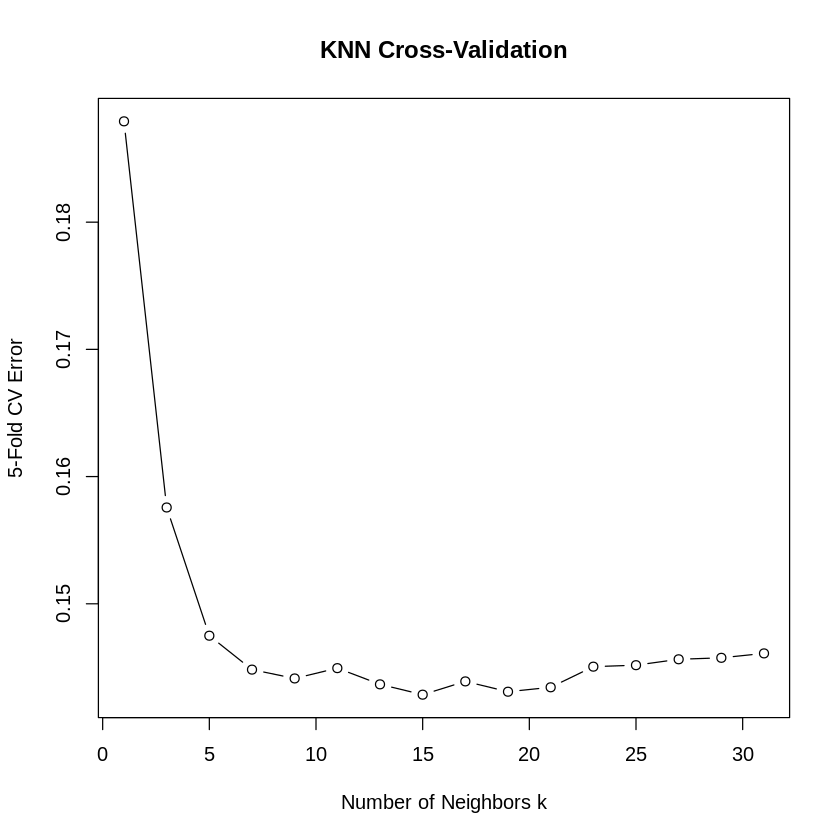

In [ ]:
# KNN is distance-based, so scale predictors using training means/sds.

train_means <- apply(x_train, 2, mean)
train_sds   <- apply(x_train, 2, sd)

# Avoid dividing by zero
train_sds[train_sds == 0] <- 1

x_train_scaled <- scale(x_train, center = train_means, scale = train_sds)
x_test_scaled  <- scale(x_test, center = train_means, scale = train_sds)

############################################################
# Cross-validation for KNN
############################################################

set.seed(432)

k_values <- seq(1, 31, by = 2)
folds <- sample(rep(1:5, length.out = nrow(x_train_scaled)))

cv_error <- rep(NA, length(k_values))

for (i in seq_along(k_values)) {

  k <- k_values[i]
  fold_errors <- rep(NA, 5)

  for (j in 1:5) {

    cv_train_x <- x_train_scaled[folds != j, ]
    cv_valid_x <- x_train_scaled[folds == j, ]

    cv_train_y <- y_train[folds != j]
    cv_valid_y <- y_train[folds == j]

    cv_pred <- knn(
      train = cv_train_x,
      test = cv_valid_x,
      cl = cv_train_y,
      k = k
    )

    fold_errors[j] <- mean(cv_pred != cv_valid_y)
  }

  cv_error[i] <- mean(fold_errors)
}

knn_cv_results <- data.frame(
  k = k_values,
  CV_Error = cv_error
)

print(knn_cv_results)

# Plot CV error
plot(
  knn_cv_results$k,
  knn_cv_results$CV_Error,
  type = "b",
  xlab = "Number of Neighbors k",
  ylab = "5-Fold CV Error",
  main = "KNN Cross-Validation"
)

best_k <- knn_cv_results$k[which.min(knn_cv_results$CV_Error)]
best_k

# Final KNN model on test set
knn_pred <- knn(
  train = x_train_scaled,
  test = x_test_scaled,
  cl = y_train,
  k = best_k
)

knn_results <- evaluate_model(
  actual = y_test,
  predicted = knn_pred,
  model_name = paste("KNN, k =", best_k)
)


# 8. Decision Tree with pruning



Classification tree:
rpart(formula = Revenue ~ ., data = train, method = "class", 
    control = rpart.control(cp = 0.001))

Variables actually used in tree construction:
 [1] Administrative          Administrative_Duration BounceRates            
 [4] Browser                 ExitRates               Informational          
 [7] Informational_Duration  Month                   OperatingSystems       
[10] PageValues              ProductRelated          ProductRelated_Duration
[13] Region                  TrafficType            

Root node error: 1335/8631 = 0.15468

n= 8631 

          CP nsplit rel error  xerror     xstd
1  0.1925094      0   1.00000 1.00000 0.025164
2  0.1138577      1   0.80749 0.80749 0.023007
3  0.0486891      2   0.69363 0.69663 0.021578
4  0.0104869      3   0.64494 0.66367 0.021121
5  0.0067416      7   0.60300 0.67790 0.021320
6  0.0052434      8   0.59625 0.65768 0.021036
7  0.0041199     13   0.56629 0.66292 0.021111
8  0.0037453     16   0.55356 0.65768 0.02

Warning message:
“labs do not fit even at cex 0.15, there may be some overplotting”


[1] 0.002996255

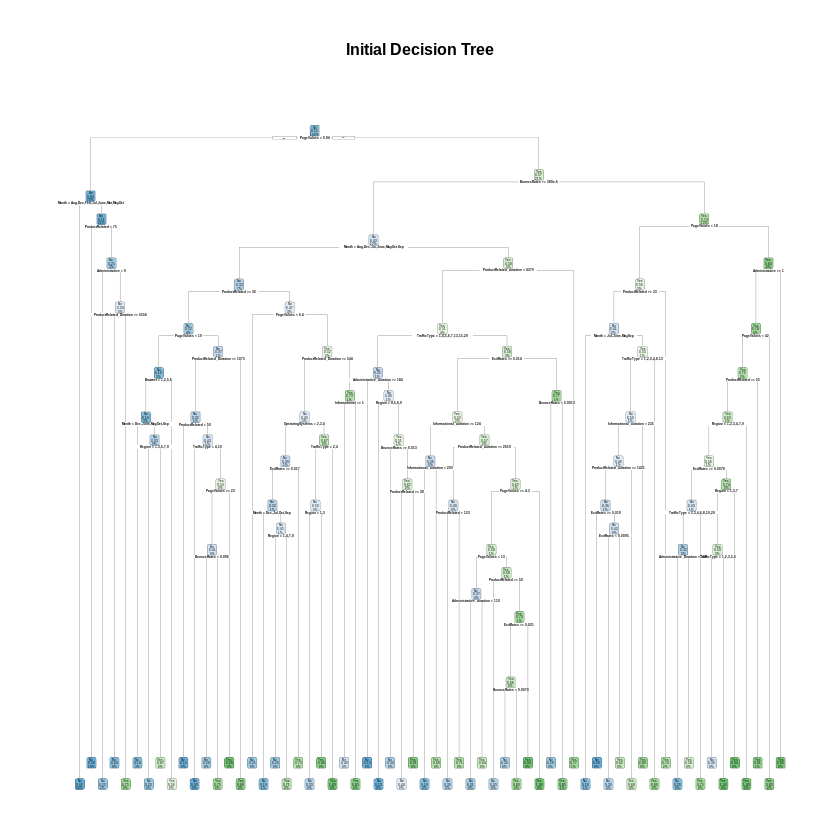

[1] "Pruned Decision Tree"
      Predicted
Actual   No  Yes
   No  2971  155
   Yes  221  352
                 Model  Accuracy Sensitivity Specificity Balanced_Accuracy
1 Pruned Decision Tree 0.8983509   0.6143106   0.9504159         0.7823633


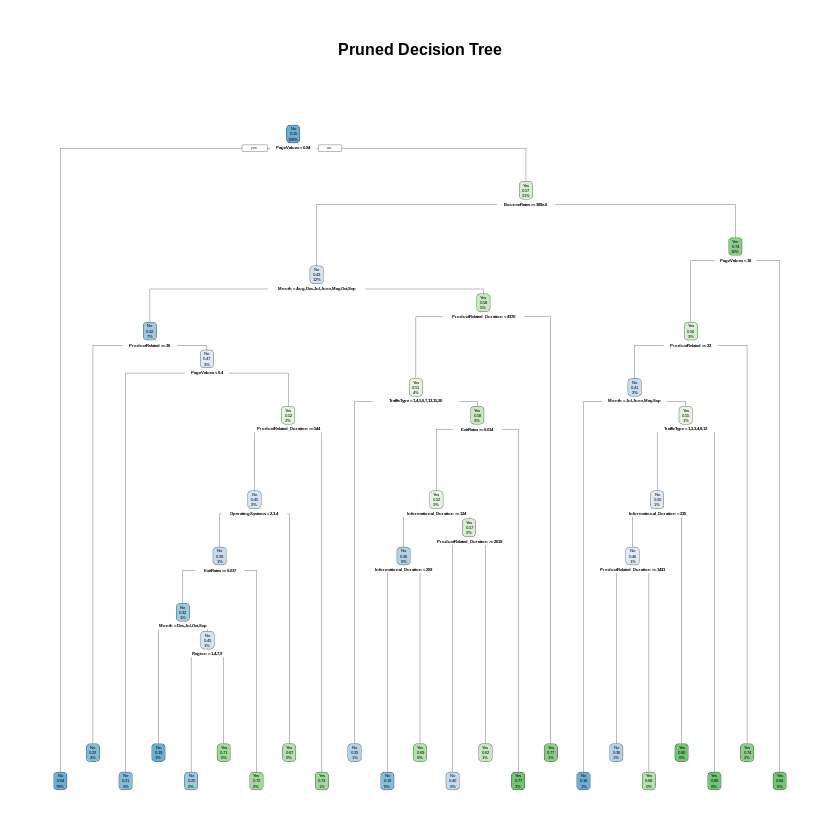

In [ ]:
tree_fit <- rpart(
  Revenue ~ .,
  data = train,
  method = "class",
  control = rpart.control(cp = 0.001)
)

# View complexity parameter table
printcp(tree_fit)

# Plot unpruned tree
rpart.plot(tree_fit, main = "Initial Decision Tree")

# Choose cp with minimum cross-validated error
best_cp <- tree_fit$cptable[which.min(tree_fit$cptable[, "xerror"]), "CP"]
best_cp

# Prune tree
tree_pruned <- prune(tree_fit, cp = best_cp)

# Plot pruned tree
rpart.plot(tree_pruned, main = "Pruned Decision Tree")

# Predict test classes
tree_pred <- predict(tree_pruned, newdata = test, type = "class")

tree_results <- evaluate_model(
  actual = test$Revenue,
  predicted = tree_pred,
  model_name = "Pruned Decision Tree"
)


# 9. Compare all models


In [ ]:
all_results <- rbind(
  log_results,
  lda_results,
  qda_results,
  knn_results,
  tree_results
)

print(all_results)

# Rank by balanced accuracy
all_results[order(-all_results$Balanced_Accuracy), ]

                 Model  Accuracy Sensitivity Specificity Balanced_Accuracy
1  Logistic Regression 0.8829413   0.3682373   0.9772873         0.6727623
2                  LDA 0.8799676   0.3176265   0.9830454         0.6503360
3                  QDA 0.8275210   0.6055846   0.8682022         0.7368934
4          KNN, k = 15 0.8567180   0.1308901   0.9897633         0.5603267
5 Pruned Decision Tree 0.8983509   0.6143106   0.9504159         0.7823633


,Model,Accuracy,Sensitivity,Specificity,Balanced_Accuracy
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
5,Pruned Decision Tree,0.8983509,0.6143106,0.9504159,0.7823633
3,QDA,0.8275210,0.6055846,0.8682022,0.7368934
1,Logistic Regression,0.8829413,0.3682373,0.9772873,0.6727623
2,LDA,0.8799676,0.3176265,0.9830454,0.6503360
4,"KNN, k = 15",0.8567180,0.1308901,0.9897633,0.5603267
